In [1]:
!pip install pennylane joblib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 21.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)


In [3]:
df = pd.read_csv("/content/final_parkinson_dataset_20k.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df['label'].value_counts())


Dataset Shape: (23692, 69)
   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0    -5.049674     -2.655842     -5.797033        2.039318          4.565347   
1    -4.694510     -3.233145     -0.351465        4.356241          6.318483   
2    -5.537877     -4.403431     -0.669037        5.388782          8.071620   
3    -5.538761     -3.952372     -0.695548        4.721408          8.071620   
4    -5.636402     -3.691478     -0.795280        8.335303         11.577893   

   MDVP:RAP   MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0  0.809620   4.632575    0.244655      4.542364          4.503094  ...   
1  2.763784   7.774593    0.577077     10.240199         10.768325  ...   
2  4.388825   9.655378    0.855844      7.323296          6.257359  ...   
3  3.524879   7.818847    0.706546      8.161784          7.353774  ...   
4  6.672112  12.465492    1.244252     11.182285          9.452626  ...   

      chroma_11    contrast_0    contrast

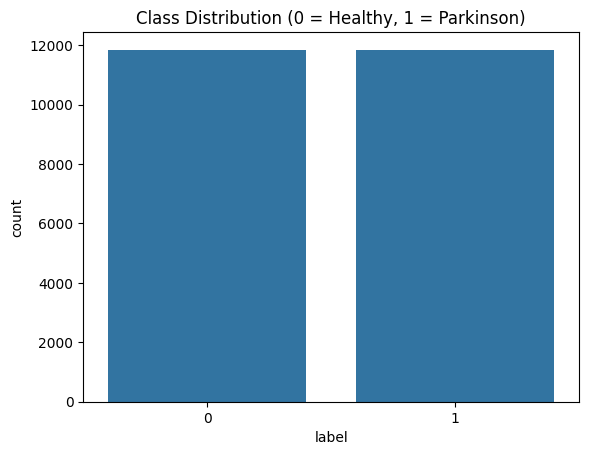

In [4]:
sns.countplot(x=df['label'])
plt.title("Class Distribution (0 = Healthy, 1 = Parkinson)")
plt.show()


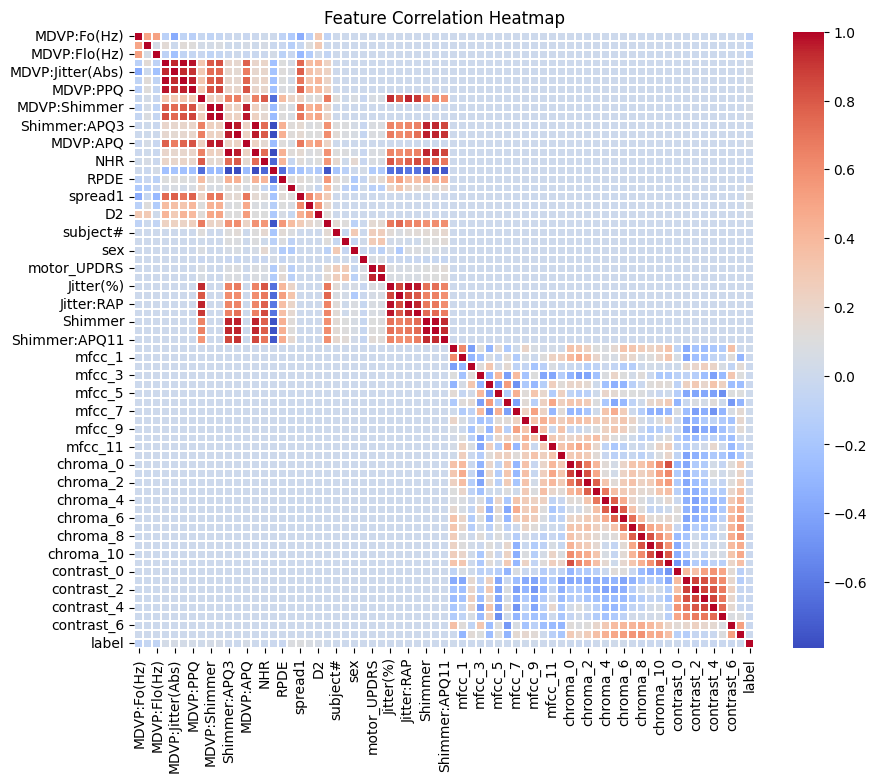

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.show()


In [6]:
X = df.drop(columns=['label'])
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, stratify=y, random_state=42
)


In [7]:
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
svm_prob = svm.predict_proba(X_test)[:,1]


In [8]:
print("===== Classical SVM (RBF) =====")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))
print("ROC-AUC:", roc_auc_score(y_test, svm_prob))
print(classification_report(y_test, svm_pred))


===== Classical SVM (RBF) =====
Accuracy: 0.9757332770626714
Precision: 0.9942982456140351
Recall: 0.9569438581680034
F1 Score: 0.9752634975263498
ROC-AUC: 0.998566487310603
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2370
           1       0.99      0.96      0.98      2369

    accuracy                           0.98      4739
   macro avg       0.98      0.98      0.98      4739
weighted avg       0.98      0.98      0.98      4739



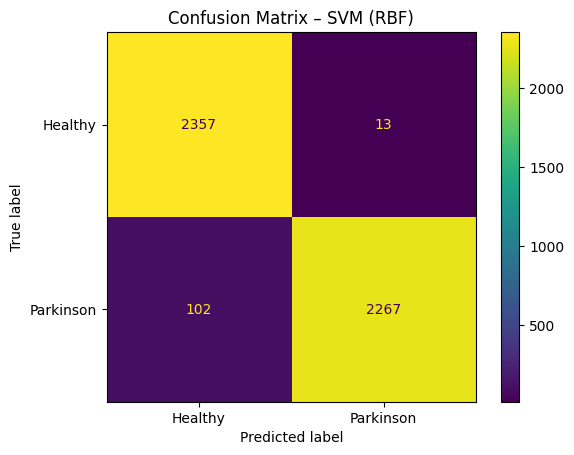

In [9]:
ConfusionMatrixDisplay.from_estimator(
    svm, X_test, y_test,
    display_labels=["Healthy", "Parkinson"]
)
plt.title("Confusion Matrix – SVM (RBF)")
plt.show()


In [10]:
X_q, _, y_q, _ = train_test_split(
    X_scaled, y, train_size=800, stratify=y, random_state=42
)

X_q = PCA(n_components=4).fit_transform(X_q)

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_q, y_q, test_size=0.2, random_state=42
)


In [11]:
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])
    return qml.state()

def quantum_kernel(x1, x2):
    return np.abs(np.vdot(feature_map(x1), feature_map(x2)))**2


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [12]:
def kernel_matrix(X1, X2):
    return np.array([[quantum_kernel(x1, x2) for x2 in X2] for x1 in X1])


In [13]:
K_train = kernel_matrix(X_train_q, X_train_q)
K_test = kernel_matrix(X_test_q, X_train_q)

qsvm = SVC(kernel="precomputed", probability=True)
qsvm.fit(K_train, y_train_q)

qsvm_pred = qsvm.predict(K_test)
qsvm_prob = qsvm.predict_proba(K_test)[:,1]


In [14]:
print("===== QSVM =====")
print("Accuracy:", accuracy_score(y_test_q, qsvm_pred))
print("Precision:", precision_score(y_test_q, qsvm_pred))
print("Recall:", recall_score(y_test_q, qsvm_pred))
print("F1 Score:", f1_score(y_test_q, qsvm_pred))
print("ROC-AUC:", roc_auc_score(y_test_q, qsvm_prob))


===== QSVM =====
Accuracy: 0.95625
Precision: 0.9868421052631579
Recall: 0.9259259259259259
F1 Score: 0.9554140127388535
ROC-AUC: 0.9842162837943429


In [15]:
noise_dev = qml.device("default.mixed", wires=n_qubits)

@qml.qnode(noise_dev)
def noisy_feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
        qml.DepolarizingChannel(0.02, wires=i)
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])
    return qml.state()

def noisy_kernel(x1, x2):
    return np.abs(np.vdot(noisy_feature_map(x1), noisy_feature_map(x2)))**2


In [16]:
def noisy_kernel_matrix(X1, X2):
    return np.array([[noisy_kernel(x1, x2) for x2 in X2] for x1 in X1])


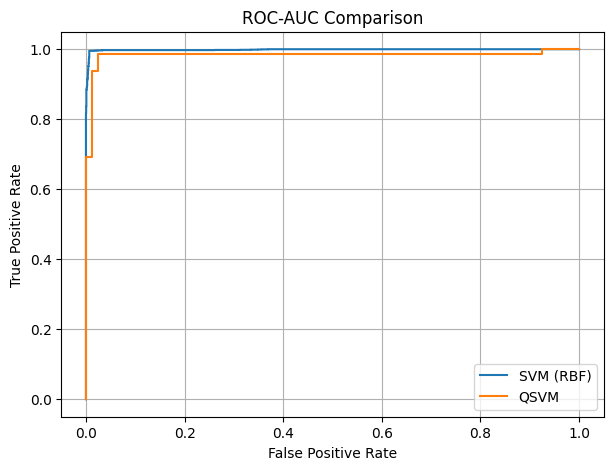

In [20]:
plt.figure(figsize=(7,5))

fpr, tpr, _ = roc_curve(y_test, svm_prob)
plt.plot(fpr, tpr, label="SVM (RBF)")

fpr, tpr, _ = roc_curve(y_test_q, qsvm_prob)
plt.plot(fpr, tpr, label="QSVM")



plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()
plt.grid()
plt.show()


In [21]:
!pip install pennylane matplotlib


In [22]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt


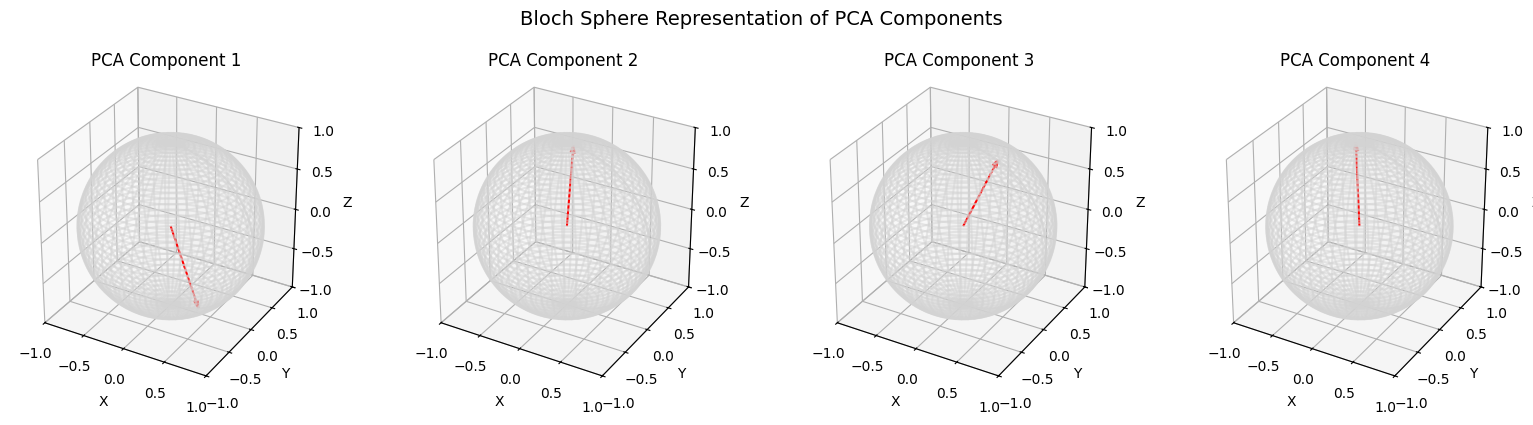

In [27]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_bloch_coords(state):
    # For a single-qubit state |psi> = a|0> + b|1>
    # Density matrix rho = |psi><psi|
    rho = np.outer(state, np.conj(state))

    # Pauli matrices
    sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
    sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)

    # Bloch vector components (x, y, z)
    x = np.trace(np.dot(rho, sigma_x)).real
    y = np.trace(np.dot(rho, sigma_y)).real
    z = np.trace(np.dot(rho, sigma_z)).real
    return x, y, z

fig, axes = plt.subplots(1, 4, figsize=(16,4), subplot_kw={'projection': '3d'})

sample = X_pca[0] # Initialize 'sample' with the first data point from X_pca

for i in range(4):
    dev = qml.device("default.qubit", wires=1)

    @qml.qnode(dev)
    def bloch_circuit(angle):
        qml.RY(angle, wires=0)
        return qml.state()

    state = bloch_circuit(sample[i])
    x_bloch, y_bloch, z_bloch = get_bloch_coords(state)

    ax = axes[i]
    ax.set_aspect("equal")

    # Draw sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightgray', alpha=0.5)

    # Plot Bloch vector
    ax.quiver(0, 0, 0, x_bloch, y_bloch, z_bloch, color='red', length=1.0, arrow_length_ratio=0.1)

    ax.set_title(f"PCA Component {i+1}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])

plt.suptitle("Bloch Sphere Representation of PCA Components", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [28]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def feature_map_visual(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return qml.state()


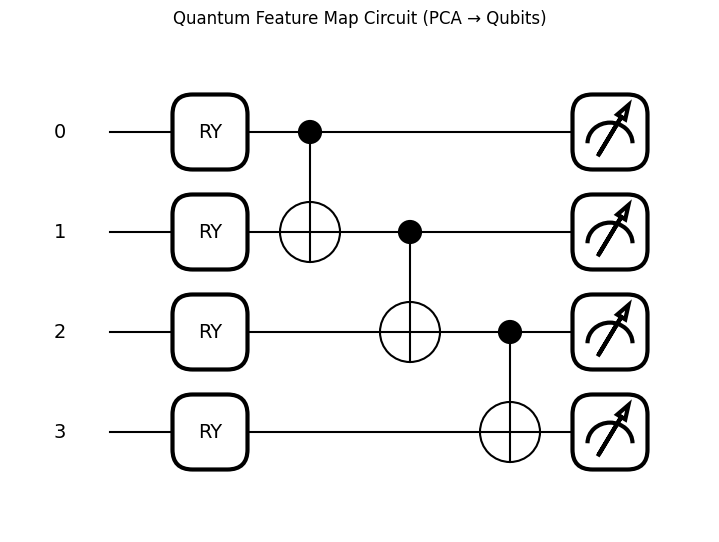

In [29]:
qml.draw_mpl(feature_map_visual)(sample)
plt.title("Quantum Feature Map Circuit (PCA → Qubits)")
plt.show()


In [30]:
sample_1 = X_pca[0]
sample_2 = X_pca[1]

@qml.qnode(dev)
def quantum_state(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    return qml.state()

state1 = quantum_state(sample_1)
state2 = quantum_state(sample_2)


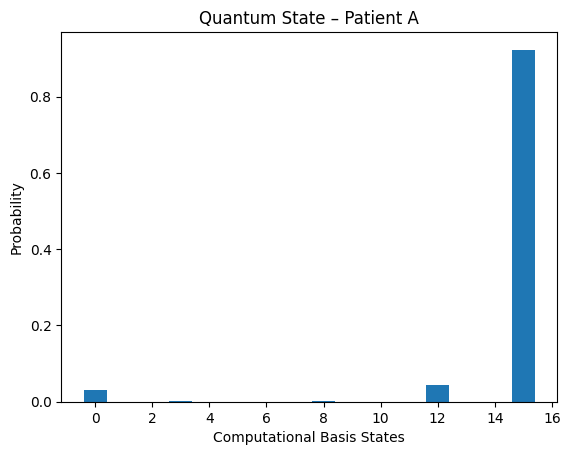

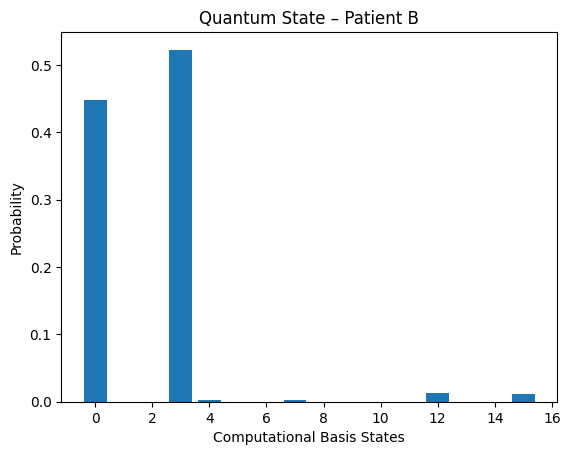

In [31]:
def plot_state_probs(state, title):
    probs = np.abs(state)**2
    plt.bar(range(len(probs)), probs)
    plt.xlabel("Computational Basis States")
    plt.ylabel("Probability")
    plt.title(title)
    plt.show()

plot_state_probs(state1, "Quantum State – Patient A")
plot_state_probs(state2, "Quantum State – Patient B")


In [32]:
kernel_value = np.abs(np.vdot(state1, state2))**2
print("Quantum Kernel Similarity:", kernel_value)


Quantum Kernel Similarity: 0.07343432200858911


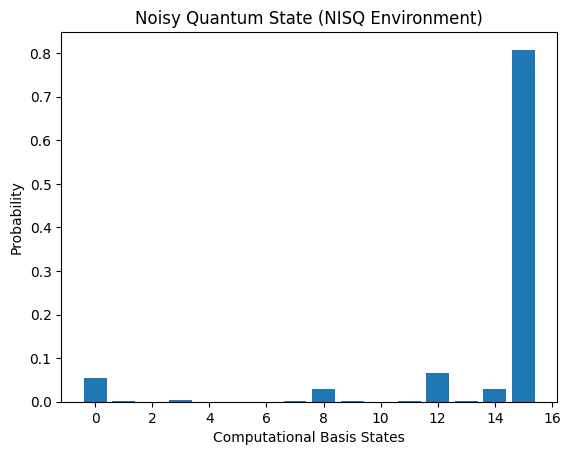

In [34]:
noise_dev = qml.device("default.mixed", wires=4)

@qml.qnode(noise_dev)
def noisy_state(x):
    for i in range(4):
        qml.RY(x[i], wires=i)
        qml.DepolarizingChannel(0.05, wires=i)
    for i in range(3):
        qml.CNOT(wires=[i, i+1])
    return qml.state()

# Redefine plot_state_probs to handle density matrices
def plot_state_probs(state, title):
    # If state is a density matrix (2D array), extract diagonal for probabilities
    if state.ndim == 2:
        probs = np.diag(state).real # Density matrix diagonals are real probabilities
    else: # Assume it's a state vector (1D array)
        probs = np.abs(state)**2

    plt.bar(range(len(probs)), probs)
    plt.xlabel("Computational Basis States")
    plt.ylabel("Probability")
    plt.title(title)
    plt.show()

noisy = noisy_state(sample_1)

plot_state_probs(noisy, "Noisy Quantum State (NISQ Environment)")

In [35]:
def decode_label(label):
    return "Parkinson Detected" if label == 1 else "Healthy Person"


In [36]:
# Predict patient status using Classical SVM
svm_predictions = svm.predict(X_test)

print("=== Classical SVM Predictions ===")
for i in range(10):  # show first 10 patients
    print(f"Patient {i+1}: {decode_label(svm_predictions[i])}")


=== Classical SVM Predictions ===
Patient 1: Parkinson Detected
Patient 2: Healthy Person
Patient 3: Parkinson Detected
Patient 4: Parkinson Detected
Patient 5: Healthy Person
Patient 6: Parkinson Detected
Patient 7: Healthy Person
Patient 8: Parkinson Detected
Patient 9: Healthy Person
Patient 10: Parkinson Detected


In [37]:
# Predict patient status using QSVM
qsvm_predictions = qsvm.predict(K_test)

print("\n=== QSVM Predictions ===")
for i in range(10):
    print(f"Patient {i+1}: {decode_label(qsvm_predictions[i])}")



=== QSVM Predictions ===
Patient 1: Healthy Person
Patient 2: Healthy Person
Patient 3: Parkinson Detected
Patient 4: Parkinson Detected
Patient 5: Parkinson Detected
Patient 6: Healthy Person
Patient 7: Healthy Person
Patient 8: Parkinson Detected
Patient 9: Parkinson Detected
Patient 10: Parkinson Detected


In [39]:
import time

# SVM timing
start = time.time()
svm.predict(X_test)
print("SVM Prediction Time:", time.time() - start, "seconds")

# QSVM timing
start = time.time()
qsvm.predict(K_test)
print("QSVM Prediction Time:", time.time() - start, "seconds")


SVM Prediction Time: 0.7106800079345703 seconds
QSVM Prediction Time: 0.0013172626495361328 seconds


In [44]:
#Prepare 2D data ONLY for visualization
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_scaled)

Xv_train, Xv_test, yv_train, yv_test = train_test_split(
    X_vis, y, test_size=0.2, stratify=y, random_state=42
)


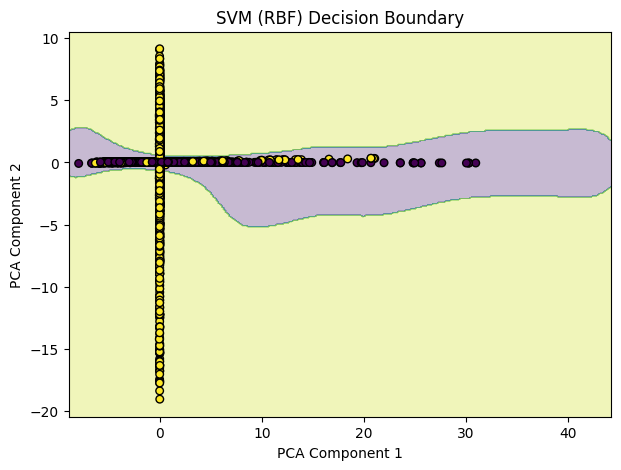

In [45]:
#from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

svm_vis = SVC(kernel="rbf")
svm_vis.fit(Xv_train, yv_train)

xx, yy = np.meshgrid(
    np.linspace(Xv_train[:,0].min()-1, Xv_train[:,0].max()+1, 300),
    np.linspace(Xv_train[:,1].min()-1, Xv_train[:,1].max()+1, 300)
)

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(Xv_test[:,0], Xv_test[:,1], c=yv_test, edgecolor='k', s=30)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM (RBF) Decision Boundary")
plt.show()


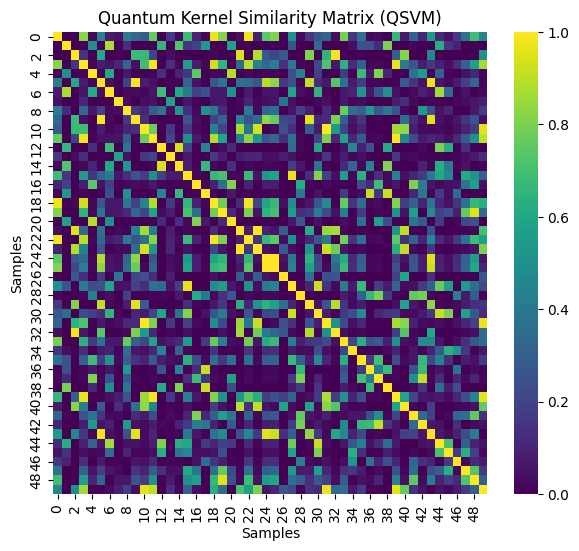

In [46]:
#QSVM KERNEL SIMILARITY HEATMAP (KEY QUANTUM FIGURE)
import seaborn as sns

# Small subset for visualization
X_k = X_train_q[:50]
y_k = y_train_q[:50]

K_q = np.array([[quantum_kernel(x1, x2) for x2 in X_k] for x1 in X_k])

plt.figure(figsize=(7,6))
sns.heatmap(K_q, cmap="viridis")
plt.title("Quantum Kernel Similarity Matrix (QSVM)")
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.show()


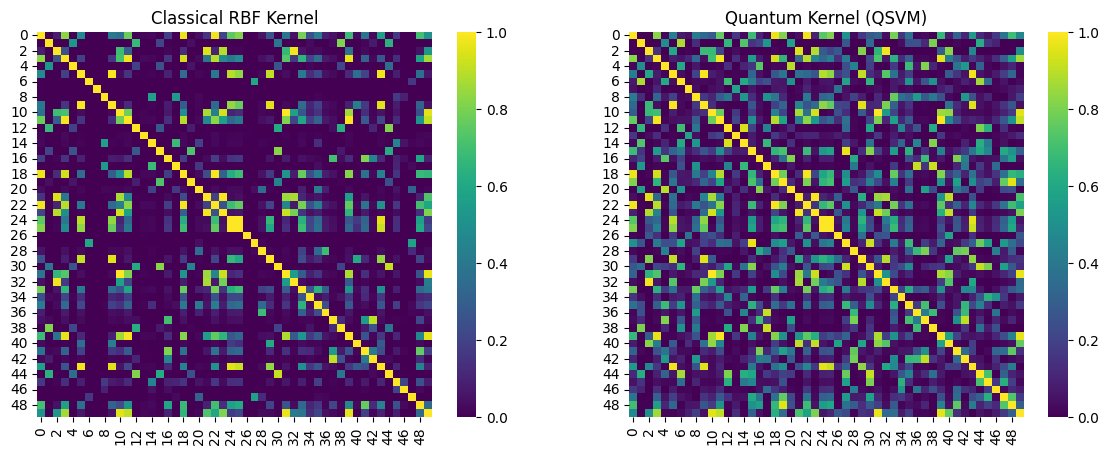

In [47]:
#CLASSICAL vs QUANTUM KERNEL COMPARISON (VERY STRONG)
from sklearn.metrics.pairwise import rbf_kernel

K_classical = rbf_kernel(X_k, X_k)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.heatmap(K_classical, cmap="viridis")
plt.title("Classical RBF Kernel")

plt.subplot(1,2,2)
sns.heatmap(K_q, cmap="viridis")
plt.title("Quantum Kernel (QSVM)")

plt.show()


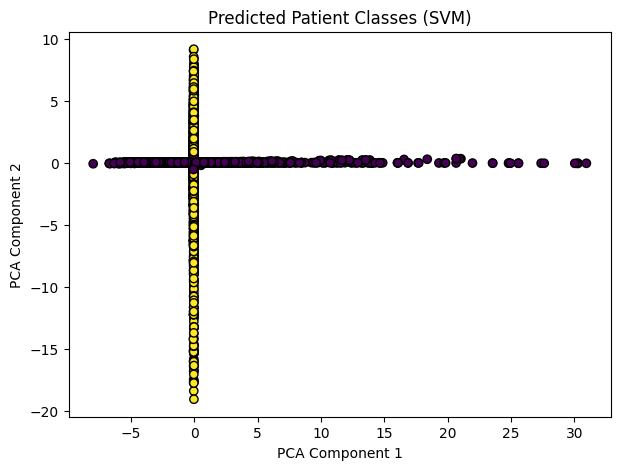

In [48]:
#FINAL PREDICTION OUTPUT VISUALIZATION
svm_preds = svm_vis.predict(Xv_test)

plt.figure(figsize=(7,5))
plt.scatter(
    Xv_test[:,0], Xv_test[:,1],
    c=svm_preds, marker='o', edgecolor='k'
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Predicted Patient Classes (SVM)")
plt.show()


In [49]:
#Code: Accurate QSVM Feature Map Circuit
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qsvm_feature_map(x):
    # Feature encoding
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

    # Entanglement
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

    return qml.state()


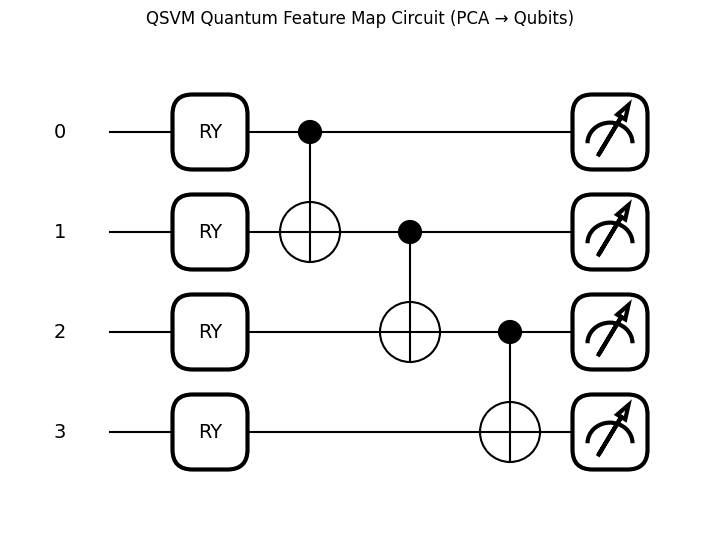

In [50]:
# Example PCA sample
sample = X_pca[0]

qml.draw_mpl(qsvm_feature_map)(sample)
plt.title("QSVM Quantum Feature Map Circuit (PCA → Qubits)")
plt.show()


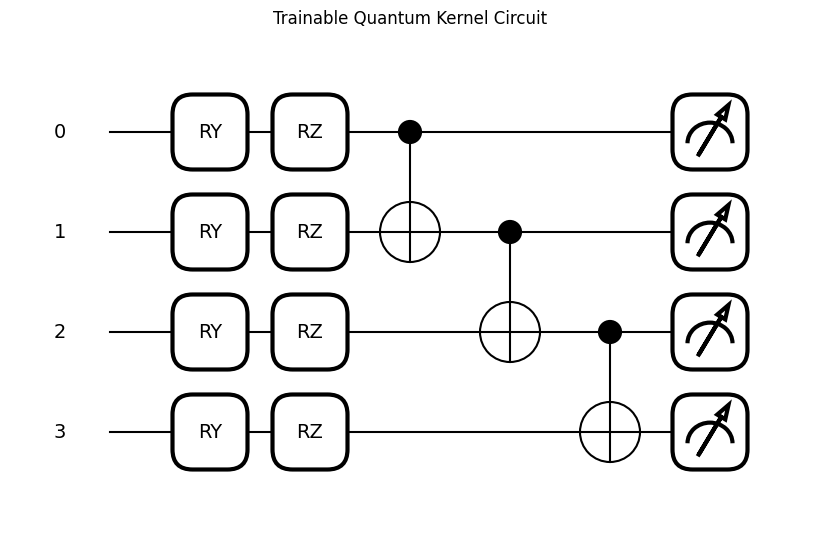

In [52]:
#Trainable Quantum Kernel Circuit
@qml.qnode(dev)
def trainable_kernel_circuit(x, theta):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
        qml.RZ(theta[i], wires=i)

    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

    return qml.state()
theta = np.random.rand(4)

qml.draw_mpl(trainable_kernel_circuit)(sample, theta)
plt.title("Trainable Quantum Kernel Circuit")
plt.show()


In [54]:
#Kernel Evaluation Concept Circuit
@qml.qnode(dev)
def kernel_overlap(x1, x2):
    # Prepare state |φ(x1)>
    for i in range(n_qubits):
        qml.RY(x1[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

    # Uncompute with |φ(x2)>
    for i in reversed(range(n_qubits - 1)):
        qml.CNOT(wires=[i, i+1])
    for i in reversed(range(n_qubits)):
        qml.RY(-x2[i], wires=i)

    return qml.probs(wires=range(n_qubits))


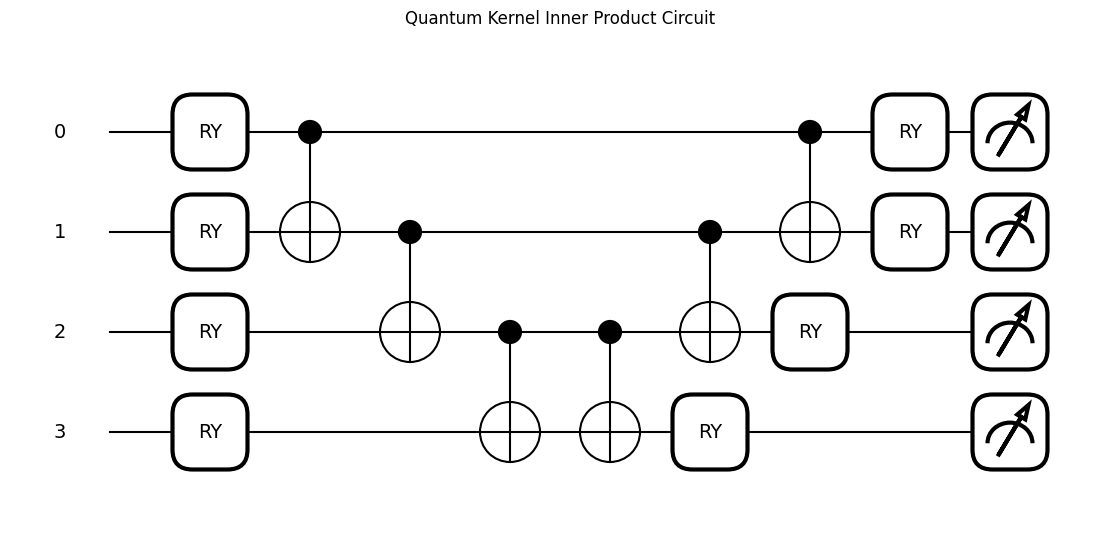

In [55]:
qml.draw_mpl(kernel_overlap)(X_pca[0], X_pca[1])
plt.title("Quantum Kernel Inner Product Circuit")
plt.show()


In [56]:
#Complete QSVM Circuit
@qml.qnode(dev)
def full_qsvm_pipeline(x, theta):
    # Encoding
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
        qml.RZ(theta[i], wires=i)

    # Feature interaction
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])

    return qml.probs(wires=range(n_qubits))


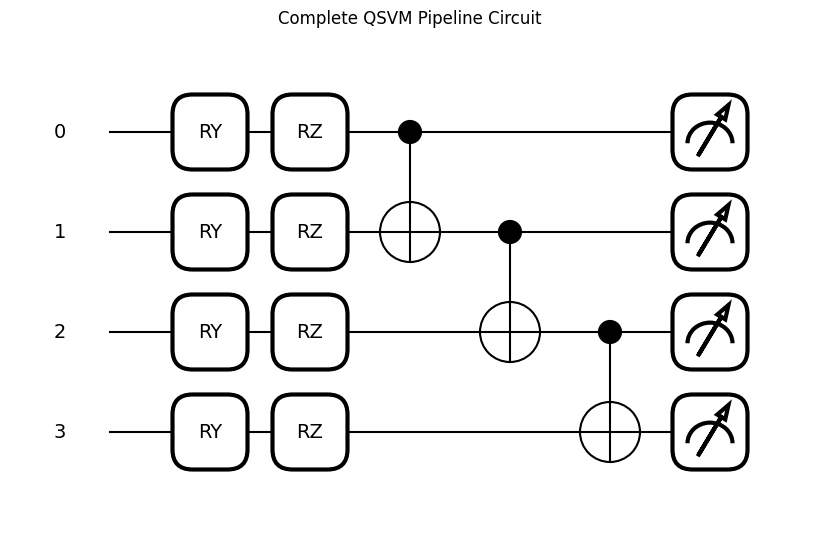

In [57]:
#Complete QSVM circuit
@qml.qnode(dev)
def full_qsvm_pipeline(x, theta):
    # Encoding
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
        qml.RZ(theta[i], wires=i)

    # Feature interaction
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])

    return qml.probs(wires=range(n_qubits))
qml.draw_mpl(full_qsvm_pipeline)(sample, theta)
plt.title("Complete QSVM Pipeline Circuit")
plt.show()
